# 1. Scipy Exercises

In [1]:
import numpy as np
from scipy import linalg

# Linear Algebra

In [2]:
# a. Define a matrix A
A = np.array([[1, -2, 3], 
              [4, 5, 6], 
              [7, 1, 9]])

# b. Define a vector b
b = np.array([1, 2, 3])

In [3]:
# c. Solve the linear system of equations A x = b
x = linalg.solve(A,b)
print(x)

[ 1.79068230e-18 -1.25347761e-17  3.33333333e-01]


In [4]:
# d. Check that your solution is correct by plugging it into the equation
print(np.matmul(A,x))

[1. 2. 3.]


In [5]:
# e. Repeat steps a-d using a random 3x3 matrix B (instead of the vector b)
B = np.random.rand(3,3)
x2 = linalg.solve(A,B)

Ax2 = np.matmul(A,x2)

print(np.allclose(Ax2, B, rtol=1e-5))

True


In [6]:
# f. Solve the eigenvalue problem for the matrix A and print the eigenvalues and eigenvectors
eig = linalg.eig(A)
eigvals = eig[0]
eigvecs = eig[1]

print(eigvals)
print(eigvecs)

[-1.13261772+0.j 10.67269524+0.j  5.45992248+0.j]
[[-0.8215735   0.05324273  0.25636602]
 [-0.02150583  0.74309552 -0.93563185]
 [ 0.56969684  0.66706391 -0.24263037]]


In [7]:
# g. Calculate the inverse, determinant of A
inv = linalg.inv(A)
print(inv)


[[-0.59090909 -0.31818182  0.40909091]
 [-0.09090909  0.18181818 -0.09090909]
 [ 0.46969697  0.22727273 -0.1969697 ]]


In [8]:
# h. Calculate the norm of A with different orders
for order in range(1,len(A)):
    norm = linalg.norm(A, ord=order)
    print(f"matrix norm of order {order}: {norm:.5f}")

matrix norm of order 1: 18.00000
matrix norm of order 2: 14.17366


# Statistics

In [9]:
from scipy import stats
import matplotlib.pyplot as plt

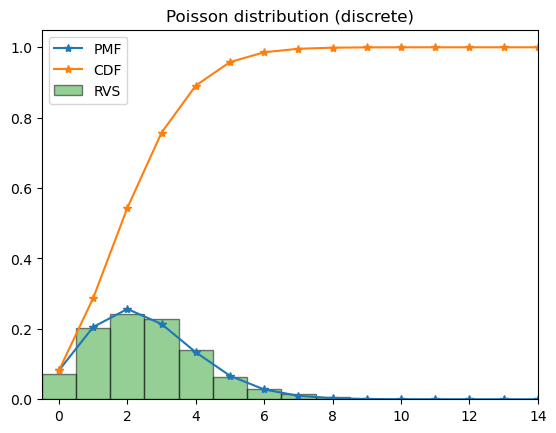

In [30]:
# a. Create a discrete random variable with poissonian distribution and plot its probability mass function (PMF), 
# cummulative distribution function (CDF) and a histogram of 1000 random realizations of the variable
mu = 2.5
#poisson = stats.poisson(mu=2.5)

x_Poi = np.arange(0,15)
pmf_Poi = stats.poisson.pmf(x_Poi, mu=mu)
cdf_Poi = stats.poisson.cdf(x_Poi, mu=mu)

rvs_Poi = stats.poisson.rvs(size=1000, mu=mu, loc=0)

plt.title("Poisson distribution (discrete)")
plt.plot(x_Poi, pmf_Poi, '-*', label="PMF")
plt.plot(x_Poi, cdf_Poi, '-*', label="CDF")
plt.hist(rvs_Poi, bins=x_Poi-0.5, density=True, label="RVS", alpha=0.5, edgecolor='black')
plt.xlim(x_Poi[0]-0.5, x_Poi[-1])
plt.legend()

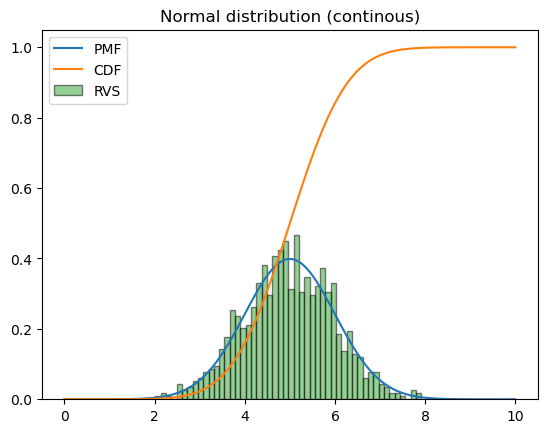

In [33]:
# b. Create a continious random variable with normal distribution and plot its probability mass function (PMF), 
# cummulative distribution function (CDF) and a histogram of 1000 random realizations of the variable

mu0 = 5
sigma = 1

x_Gauss = np.linspace(0,10,100)

pmf_Gauss = stats.norm.pdf(x, loc=mu0, scale=sigma)
cdf_Gauss = stats.norm.cdf(x, loc=mu0, scale=sigma)
rvs_Gauss = stats.norm.rvs(size=1000, loc=mu0, scale=sigma)

plt.title("Normal distribution (continous)")
plt.plot(x, pmf_Gauss, label="PMF")
plt.plot(x, cdf_Gauss, label="CDF")
plt.hist(rvs_Gauss, bins=50, density=True, label="RVS", alpha=0.5, edgecolor='black')
plt.legend()


In [63]:
# c. Test if two sets of (independent) random data comes from the same distribution
T = stats.ttest_ind(rvs_Gauss, rvs_Poi)
print(T)

rvs_Gauss2 = stats.norm.rvs(size=1000, loc=mu0, scale=sigma)
T2 = stats.ttest_ind(rvs_Gauss, rvs_Gauss2)
print(T2)

TtestResult(statistic=np.float64(39.58788115249453), pvalue=np.float64(1.558924494869535e-253), df=np.float64(1998.0))
TtestResult(statistic=np.float64(-1.8612169553647024), pvalue=np.float64(0.06286031365820195), df=np.float64(1998.0))
